# California Housing - Feature Engineering

- [Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices)


Install packages


In [1]:
!uv pip install -q \
    python-dotenv==1.2.1 \
    pandas==2.3.2 \
    pandas-stubs==2.3.2.250827 \
    numpy==2.3.2 \
    matplotlib==3.10.6 \
    seaborn==0.13.2 \
    scikit-learn==1.7.1 \
    tqdm==4.67.1 \
    plotly==6.6.0 \
    nbformat==4.2.0

Append notebooks directory to sys.path


In [ ]:
import sys

sys.path.append("../../..")

Import packages


In [3]:
import os
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    mean_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from notebooks.python.utils.data_extraction.data_extraction import (
    KaggleDataExtractor,
    KaggleExtractionConfig,
)
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import plotly.express as px


pd.set_option("display.max_columns", None)

sns.set_style("darkgrid")
sns.set_theme(style="darkgrid")

%matplotlib inline

load_dotenv()  # Root directory .env file

True

## Utility scripts:

**KaggleDataExtractor**:

```py
--8<-- "docs/notebooks/python/utils/data_extraction/data_extraction.py"
```


Create data directory


In [ ]:
DATA_DIR = pathlib.Path("data/california-housing-feature-engineering")

os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
username = os.getenv("KAGGLE_USERNAME")
api_token = os.getenv("KAGGLE_API_TOKEN")
file_name = "housing.csv"

extractor = KaggleDataExtractor(username=username, api_token=api_token)

config = KaggleExtractionConfig(
    dataset_slug="camnugent/california-housing-prices",
    file_name=file_name,
    destination_path=DATA_DIR,
    output_file_name="housing.csv",
)

if not os.path.isfile(DATA_DIR / "housing.csv"):
    extractor.download_dataset(config)

Load dataset


In [ ]:
df = pd.read_csv(DATA_DIR / "housing.csv")

df.head(n=2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [ ]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


## Split


In [ ]:
len(df) * 0.8

16346.400000000001

In [ ]:
df = df.sample(frac=1, random_state=2)
train_df = df[:17000]
train_df = train_df.reset_index(drop=True)
test_df = df[17000:]
test_df = test_df.reset_index(drop=True)

train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.16,37.76,36.0,2781.0,574.0,1438.0,519.0,2.4598,155500.0,NEAR BAY
1,-119.95,36.80,30.0,1233.0,214.0,620.0,199.0,3.4297,112500.0,INLAND
2,-118.49,34.42,23.0,4166.0,756.0,2082.0,743.0,4.4107,213400.0,<1H OCEAN
3,-122.24,37.79,27.0,1632.0,492.0,1171.0,429.0,2.3173,125000.0,NEAR BAY
4,-121.45,36.86,11.0,1613.0,335.0,1617.0,342.0,3.1375,146200.0,INLAND


Converting target variables as array


In [ ]:
y_train = train_df["median_house_value"].to_numpy()
y_test = test_df["median_house_value"].to_numpy()

y_train.shape, y_test.shape

((17000,), (3433,))

Baseline model, setting the result for every median_house_value as mean


In [ ]:
average_median_house_value = train_df["median_house_value"].mean()
baseline_model_test_predictions = [average_median_house_value] * len(test_df)

mean_absolute_error(baseline_model_test_predictions, y_test)

90952.86688447764

## Dimensionality Reduction

As dimensions increase, data becomes sparse, it is difficult for the model see patterns because there are no dense regions

- It makes overfit more easily because the model can fit noise
- Computational cost increases (more memory usage, training time increases, inference latency)
- Feature redundance for correlated features and irrelevance for features that are just noise (does not mean anything)
- Model stability, small changes in data can do big changes in predictions
- Harder to debug and interpret

Features are like questions in an exam:

- 10 good questions measure knowledge
- 1000 random questions are just noise


**Correlation**:

- When the value is positive while a variable increase the other increase also
- When the value is negative while a variable decrease the other increase


### Feature extraction: PCA

- Compress information

PCA is helpful for:

- KNN: Compress data and improves distance calculations
- K-means: Compress data and improves distance calculations
- SVM: Faster training and less overfitting

But usually unnecessary for:

- Neural networks: Learn their own feature representation and already got Hidden layers that act as automatic feature selection
- Tree models: With PCA trees can't exploit original feature meaning and loose interpretability


In [ ]:
train_df[["total_rooms", "total_bedrooms", "households"]].corr()

,total_rooms,total_bedrooms,households
total_rooms,1.000000,0.931023,0.918161
total_bedrooms,0.931023,1.000000,0.979402
households,0.918161,0.979402,1.000000


In [ ]:
X_train_3 = train_df[
    ["total_rooms", "total_bedrooms", "households"]
].to_numpy()

X_train_3.shape

(17000, 3)

In [ ]:
X_test_3 = test_df[["total_rooms", "total_bedrooms", "households"]].to_numpy()

X_test_3.shape

(3433, 3)

In [ ]:
forest_base = RandomForestRegressor(n_estimators=50, max_depth=5).fit(
    X_train_3, y_train
)
forest_base_test_predictions = forest_base.predict(X_test_3)
mean_absolute_error(y_test, forest_base_test_predictions)

82353.62932794042

Transform the 3 columns from X_train in 2 keeping the variance


In [ ]:
pca = PCA(n_components=2)
pca = pca.fit(X_train_3)

print(pca)

PCA(n_components=2)


In [ ]:
X_train_pca = pca.transform(X_train_3)
X_test_pca = pca.transform(X_test_3)

X_train_pca.shape, X_test_pca.shape

((17000, 2), (3433, 2))

In [ ]:
forest_pca = RandomForestRegressor(n_estimators=50, max_depth=5).fit(
    X_train_pca, y_train
)
forest_pca_test_predictions = forest_pca.predict(X_test_pca)

mean_absolute_error(y_test, forest_pca_test_predictions)

79370.2691703226

## Preprocessing / Scaling

- Transform features in comparable scale
- Avoid distances to be distorted
- Avoid one feature dominate the model
- Improves optimization (mainly for neural networks)

Used for models which distance is important:

- KNN
- K-means
- SVM
- Neural networks
- PCA

Without it, regularization penalties unevenly

Usually **NOT** needed:

- Tree models (Random Forest, XGBoost): Trees don’t use distance, they split by thresholds


Get each value, _subtract_ by **mean** and _divide_ by **standard deviation**

- Mean = 0
- Standard deviation = 1


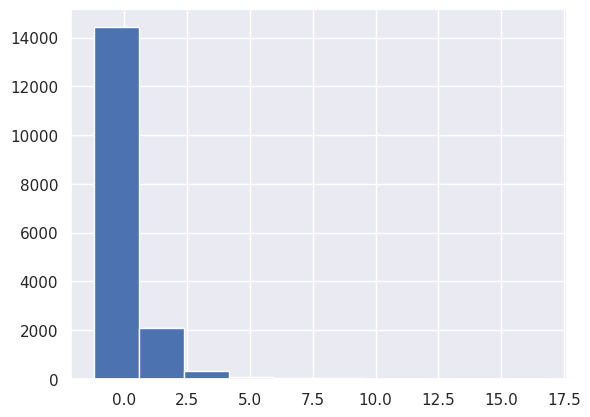

In [ ]:
scaler = StandardScaler().fit(X_train_3)
X_train_3_scaled = scaler.transform(X_train_3)

plt.hist(X_train_3_scaled[:, 0])
plt.show()

Make values go between 0 and 1, when we already have a maximum known number like RGB (255)

- Small values like 0 to 1 are easily to work than 0 to 255


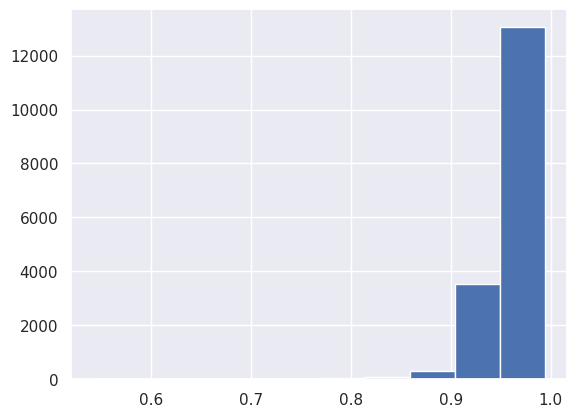

In [ ]:
normalizer = Normalizer().fit(X_train_3)
X_train_3_normalized = normalizer.transform(X_train_3)

plt.hist(X_train_3_normalized[:, 0])
plt.show()

In [ ]:
scaler = StandardScaler().fit(X_train_3)
X_train_3_scaled = scaler.transform(X_train_3)

X_test_3_scaled = scaler.transform(X_test_3)

X_train_3_scaled.shape, X_test_3_scaled.shape

((17000, 3), (3433, 3))

In [ ]:
random_forest_scaled = RandomForestRegressor(n_estimators=50, max_depth=5).fit(
    X_train_3_scaled, y_train
)
random_forest_scaled_test_predictions = random_forest_scaled.predict(
    X_test_3_scaled
)

mean_absolute_error(y_test, random_forest_scaled_test_predictions)

82187.41885158629

Create pipeline with `StandardScaler`


In [ ]:
scale_pca_pipe_forest = Pipeline(
    steps=[
        ("Scaler", StandardScaler()),
        ("PCA", PCA(n_components=2)),
        ("Forest", RandomForestRegressor(n_estimators=50, max_depth=5)),
    ]
)

scale_pca_pipe_forest.fit(X_train_3, y_train)
scale_pca_pipe_forest_test_predictions = scale_pca_pipe_forest.predict(
    X_test_3
)

mean_absolute_error(y_test, scale_pca_pipe_forest_test_predictions)

80198.9302401591

Create pipeline with `Normalizer`


In [ ]:
scale_pca_pipe_forest = Pipeline(
    steps=[
        ("Scaler", Normalizer()),
        ("PCA", PCA(n_components=2)),
        ("Forest", RandomForestRegressor(n_estimators=50, max_depth=5)),
    ]
)

scale_pca_pipe_forest.fit(X_train_3, y_train)
scale_pca_pipe_forest_test_predictions = scale_pca_pipe_forest.predict(
    X_test_3
)

mean_absolute_error(y_test, scale_pca_pipe_forest_test_predictions)

77346.30550039872

## Categorical Encoding

### Dummy / One-Hot

- Making categorical data usable for models that expect numbers, without introducing fake order

**Example**:

Color = {Red, Blue, Green}

If you encode like this:

Red = 1
Blue = 2
Green = 3

You just told the model:

Green > Blue > Red
Distance(Green, Red) = 2

What should be:

| Red | Blue | Green |
| --- | ---- | ----- |
| 1   | 0    | 0     |

Models:

- **Linear Regression**: Needs numeric relationships and linear combinations
- **Logistic Regression**: Needs numeric relationships and linear combinations
- **KNN**: Distance depends on numeric values
- **K-means**: Distance depends on numeric values
- **SVM** (especially linear): Distance depends on numeric values

Which models do NOT need one-hot:

- Random Forest
- XGBoost
- LightGBM

These models split like:

`if color == "Red"`

They don’t rely on:

- Distance
- Linear relationships (When one variable change the other change at constant rate)

Observation: One-hot can increase dimensionality

Avoid one-hot when:

- High cardinality (hundreds/thousands)
- Using tree models
- Memory/performance matters


In [ ]:
train_dummies = pd.get_dummies(train_df["ocean_proximity"])
train_dummies.head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,False,False,False,True,False
1,False,True,False,False,False
2,True,False,False,False,False
3,False,False,False,True,False
4,False,True,False,False,False


In [ ]:
train_df = pd.concat([train_df, train_dummies], axis=1)
train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.16,37.76,36.0,2781.0,574.0,1438.0,519.0,2.4598,155500.0,NEAR BAY,False,False,False,True,False
1,-119.95,36.80,30.0,1233.0,214.0,620.0,199.0,3.4297,112500.0,INLAND,False,True,False,False,False
2,-118.49,34.42,23.0,4166.0,756.0,2082.0,743.0,4.4107,213400.0,<1H OCEAN,True,False,False,False,False
3,-122.24,37.79,27.0,1632.0,492.0,1171.0,429.0,2.3173,125000.0,NEAR BAY,False,False,False,True,False
4,-121.45,36.86,11.0,1613.0,335.0,1617.0,342.0,3.1375,146200.0,INLAND,False,True,False,False,False


In [ ]:
train_df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7522
INLAND        5408
NEAR OCEAN    2172
NEAR BAY      1895
ISLAND           3
Name: count, dtype: int64

Drop the column with less occurrences


In [ ]:
train_df.drop("ISLAND", inplace=True, axis=1, errors="ignore")
train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.16,37.76,36.0,2781.0,574.0,1438.0,519.0,2.4598,155500.0,NEAR BAY,False,False,True,False
1,-119.95,36.80,30.0,1233.0,214.0,620.0,199.0,3.4297,112500.0,INLAND,False,True,False,False
2,-118.49,34.42,23.0,4166.0,756.0,2082.0,743.0,4.4107,213400.0,<1H OCEAN,True,False,False,False
3,-122.24,37.79,27.0,1632.0,492.0,1171.0,429.0,2.3173,125000.0,NEAR BAY,False,False,True,False
4,-121.45,36.86,11.0,1613.0,335.0,1617.0,342.0,3.1375,146200.0,INLAND,False,True,False,False


In [ ]:
test_dummies = pd.get_dummies(test_df["ocean_proximity"])
test_dummies.head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,False,True,False,False,False
4,True,False,False,False,False


In [ ]:
test_df = pd.concat([test_df, test_dummies], axis=1)
test_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-118.07,33.87,28.0,2399.0,436.0,1613.0,429.0,3.6339,220100.0,<1H OCEAN,True,False,False,False,False
1,-118.26,34.02,40.0,1259.0,362.0,1499.0,327.0,1.8382,126400.0,<1H OCEAN,True,False,False,False,False
2,-118.51,34.16,23.0,11154.0,1995.0,4076.0,1809.0,5.4609,500001.0,<1H OCEAN,True,False,False,False,False
3,-120.04,36.95,36.0,1528.0,347.0,1334.0,304.0,1.3594,48300.0,INLAND,False,True,False,False,False
4,-117.91,33.65,24.0,1494.0,494.0,814.0,459.0,2.1074,181300.0,<1H OCEAN,True,False,False,False,False


In [ ]:
test_df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     1512
INLAND        1088
NEAR OCEAN     456
NEAR BAY       375
ISLAND           2
Name: count, dtype: int64

In [ ]:
test_df.drop("ISLAND", inplace=True, axis=1, errors="ignore")
test_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-118.07,33.87,28.0,2399.0,436.0,1613.0,429.0,3.6339,220100.0,<1H OCEAN,True,False,False,False
1,-118.26,34.02,40.0,1259.0,362.0,1499.0,327.0,1.8382,126400.0,<1H OCEAN,True,False,False,False
2,-118.51,34.16,23.0,11154.0,1995.0,4076.0,1809.0,5.4609,500001.0,<1H OCEAN,True,False,False,False
3,-120.04,36.95,36.0,1528.0,347.0,1334.0,304.0,1.3594,48300.0,INLAND,False,True,False,False
4,-117.91,33.65,24.0,1494.0,494.0,814.0,459.0,2.1074,181300.0,<1H OCEAN,True,False,False,False


In [ ]:
X_train_dummies = train_df.to_numpy()[:, -4:]
X_train_dummies.shape

(17000, 4)

In [ ]:
X_test_dummies = test_df.to_numpy()[:, -4:]
X_test_dummies.shape

(3433, 4)

In [ ]:
linear_dummy = LinearRegression().fit(X_train_dummies, y_train)
linear_dummy_test_predictions = linear_dummy.predict(X_test_dummies)

mean_absolute_error(y_test, linear_dummy_test_predictions)

77095.0289334857

## Binning (Grouping, Aggregating)

- Capture non-linear relationships
- Reduce noise
- Handle outliers
- Improve interpretability

Models:

- Linear Regression
- Logistic Regression
- Naive Bayes

Which models usually do NOT need binning:

- Random Forest
- XGBoost
- LightGBM
- Neural networks: They learn non-linear patterns directly
- KNN: You destroy distance meaning
- K-means: You destroy distance meaning

Trees already do this internally:

```py
if age < 35: left
else: right
```

That’s dynamic binning, if you bin manually you may lose precision and hurt performance


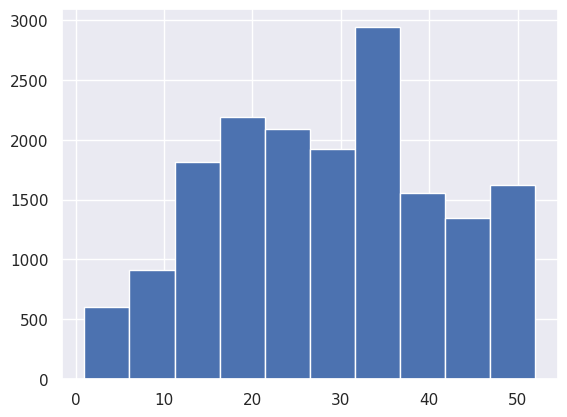

In [ ]:
train_df["housing_median_age"].hist()

plt.show()

In [ ]:
train_df["median_age_less_than_30"] = (
    train_df["housing_median_age"] < 30
).astype(int)

train_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN,median_age_less_than_30
0,-122.16,37.76,36.0,2781.0,574.0,1438.0,519.0,2.4598,155500.0,NEAR BAY,False,False,True,False,0
1,-119.95,36.80,30.0,1233.0,214.0,620.0,199.0,3.4297,112500.0,INLAND,False,True,False,False,0
2,-118.49,34.42,23.0,4166.0,756.0,2082.0,743.0,4.4107,213400.0,<1H OCEAN,True,False,False,False,1
3,-122.24,37.79,27.0,1632.0,492.0,1171.0,429.0,2.3173,125000.0,NEAR BAY,False,False,True,False,1
4,-121.45,36.86,11.0,1613.0,335.0,1617.0,342.0,3.1375,146200.0,INLAND,False,True,False,False,1


In [ ]:
X_train_median_age = (
    train_df["median_age_less_than_30"].to_numpy().reshape(-1, 1)
)
X_train_median_age.shape

(17000, 1)

In [ ]:
test_df["median_age_less_than_30"] = (
    test_df["housing_median_age"] < 30
).astype(int)

test_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN,median_age_less_than_30
0,-118.07,33.87,28.0,2399.0,436.0,1613.0,429.0,3.6339,220100.0,<1H OCEAN,True,False,False,False,1
1,-118.26,34.02,40.0,1259.0,362.0,1499.0,327.0,1.8382,126400.0,<1H OCEAN,True,False,False,False,0
2,-118.51,34.16,23.0,11154.0,1995.0,4076.0,1809.0,5.4609,500001.0,<1H OCEAN,True,False,False,False,1
3,-120.04,36.95,36.0,1528.0,347.0,1334.0,304.0,1.3594,48300.0,INLAND,False,True,False,False,0
4,-117.91,33.65,24.0,1494.0,494.0,814.0,459.0,2.1074,181300.0,<1H OCEAN,True,False,False,False,1


In [ ]:
X_test_median_age = (
    test_df["median_age_less_than_30"].to_numpy().reshape(-1, 1)
)
X_test_median_age.shape

(3433, 1)

In [ ]:
linear_median_age = LinearRegression().fit(X_train_median_age, y_train)
linear_median_age_test_predictions = linear_median_age.predict(
    X_test_median_age
)
mean_absolute_error(y_test, linear_median_age_test_predictions)

90794.78827572097

## Clustering

Group similar data points together without labels

Example:

- Customers: grouped by behavior
- Transactions: grouped by patterns

Sometimes labels are unknown and clustering reveal patterns you did not defined

Example:

- Customer segments
- Fraud patterns
- User behavior

Cluster outputs can be used as features:

- Cluster ID
- Distance to cluster centers

Data compression and summarization

- Large scale systems
- Preprocessing pipelines

Anomaly detection:

- Fraud detection
- System monitoring

Models that could benefit:

- Linear models
- Tree models

Clustering algorithms:

- K-means
- DBScan
- Hierarchical clustering

For linear algorithms, clustering works like binning

Clustering is often combined with PCA and standardization

Clustering works well when:

- Distance/similarity is meaningful
- No labels are available
  You believe data has natural groups


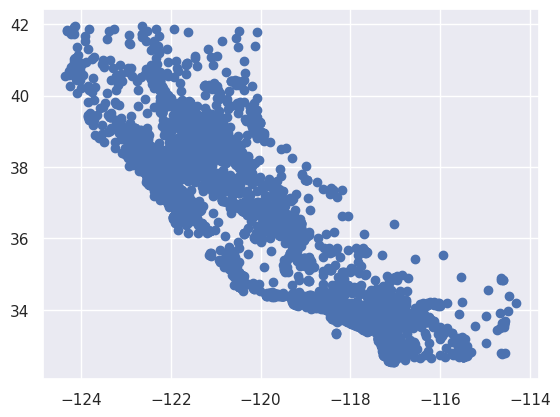

In [ ]:
plt.scatter(train_df["longitude"], train_df["latitude"])

plt.show()

In [ ]:
X_train_lat_long = train_df[["longitude", "latitude"]].to_numpy()
kmeans = KMeans(n_clusters=7).fit(X_train_lat_long)
kmeans.labels_

array([0, 3, 5, ..., 2, 5, 5], shape=(17000,), dtype=int32)

In [ ]:
px.scatter(
    x=train_df["longitude"], y=train_df["latitude"], color=kmeans.labels_
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<br>color=%{marker.color}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': {'bdata': ('AAAAAAMAAAAFAAAAAAAAAAAAAAADAA' ... 'AAAQAAAAIAAAACAAAABQAAAAUAAAA='),
                                   'dtype': 'i4'},
                         'coloraxis': 'coloraxis',
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': {'bdata': ('CtejcD2KXsDNzMzMzPxdwI/C9Shcn1' ... 'oUXl7A16NwPQq3XcCPwvUoXI9dwA=='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': ('4XoUrkfhQkBmZmZmZmZCQPYoXI/CNU' ... 'AAQENAexSuR+EaQUDXo3A9CvdAQA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'coloraxis': {'colorbar': {'title': {'text': 'color'}},
                             'colorscale': [[0.0, '#0d0887'], [0.1111111111111111,
                                            '#46039f'], [0.2222222222222222,
                                            '#7201a8'], [0.3333333333333333,
                                            '#9c179e'], [0.4444444444444444,
                                            '#bd3786'], [0.5555555555555556,
                                            '#d8576b'], [0.6666666666666666,
                                            '#ed7953'], [0.7777777777777778,
                                            '#fb9f3a'], [0.8888888888888888,
                                            '#fdca26'], [1.0, '#f0f921']]},
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})

In [ ]:
X_train_clustering = pd.get_dummies(pd.Series(kmeans.labels_)).to_numpy()
X_train_clustering

array([[ True, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False,  True, False]], shape=(17000, 7))

In [ ]:
X_test_lat_long = test_df[["longitude", "latitude"]].to_numpy()
X_test_clustering = pd.get_dummies(
    pd.Series(kmeans.predict(X_test_lat_long))
).to_numpy()
X_test_clustering.shape

(3433, 7)

In [56]:
linear_clustering = LinearRegression().fit(X_train_clustering, y_train)
linear_clustering_test_predictions = linear_clustering.predict(
    X_test_clustering
)

mean_absolute_error(linear_clustering_test_predictions, y_test)

75498.33350007689